In [1]:
import numpy as np  
import pandas as pd  
import yfinance as yf  
import matplotlib.pyplot as plt 
from scipy.optimize import minimize

### Problem Constants

In [2]:
coins = ['BTC-USD', 'ETH-USD', 'XRP-USD', 'SOL-USD', 'BNB-USD']

start_date, end_date = '2024-01-01', '2024-11-01'

initial_capital = 1000

risk_free_rate = 0.04

commission = 0.005

### Download Data

In [3]:
all_data = {}
Index = None

In [4]:
for coin in coins:
    data = yf.download(coin, start=start_date, end=end_date)
    all_data[coin] = data
    Index = data.index

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


### Converting Dictionary to Dataframe

In [5]:
all_data_df = pd.DataFrame(index=Index)
for coin in coins:
    all_data_df[coin] = all_data[coin]['Close']

#### Positive Random Weights with Sum of 1

In [6]:
def random_weights(n: int):
    weights = np.random.rand(n)
    return weights / np.sum(weights)

#### MPT Weights Optimization 

In [88]:
def mpt_weights(n: int, returns, objective='sharpe'):
    bounds = [(0, 1) for _ in range(n)]
    constraints = ({'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1})

    if objective == 'sharpe':
        def objective_function(weights):
            portfolio_return = np.sum(weights * returns.mean()) * 252
            portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * 252, weights)))
            return -portfolio_return / portfolio_volatility
    elif objective == 'max_drawdown':
        def objective_function(weights):
            portfolio_returns = np.sum(weights * returns, axis=1)
            cumulative_returns = np.cumsum(portfolio_returns)
            peak = np.maximum.accumulate(cumulative_returns)
            drawdown = peak - cumulative_returns
            max_drawdown = np.max(drawdown)
            return max_drawdown
    elif objective == 'risk':
         def objective_function(weights):
            portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * 252, weights)))  
            return portfolio_volatility 
    elif objective == 'return':
        def objective_function(weights):
            portfolio_return = np.sum(weights * returns.mean() * 252)  
            return -portfolio_return
    else:
        print("Failed!")
        return -1

    initial_weights = np.array([1/n]*n)

    result = minimize(objective_function, initial_weights, args=(), bounds=bounds, constraints=constraints)
    return result.x

#### Sharpe Ratio

In [8]:
def sharpe_ratio(portfolio) -> float:
    daily_returns = portfolio.pct_change().dropna()
    excess_returns = daily_returns - (risk_free_rate / 252)
    annualized_return = excess_returns.mean() * 252
    annualized_volatility = daily_returns.std() * np.sqrt(252)
    return annualized_return / annualized_volatility

#### Drawdown

In [9]:
def max_drawdown(portfolio) -> float:
    pv = portfolio.cummax()
    lp = portfolio.copy(deep=True)
    return ((lp - pv) / pv).min() * 100 

#### Expected Return

In [10]:
def excepted_return(weights, returns):
    return np.sum(returns.mean() * weights * 252)

#### Variance

In [11]:
def variance(weights, stds, cov_matrix):
    return np.sqrt(weights.T @ cov_matrix @ weights)
    # print(covars)
    # sum1 = np.sum((weights**2) * (stds**2))
    # sum2 = 0
    # for i, coin1 in enumerate(coins):
    #     for j, coin2 in enumerate(coins):
    #         if i == j:
    #             continue
    #         sum2 += weights[i] * weights[j] * stds[coin1] * stds[coin2] * covars[coin1][coin2]
    # return sum1 + sum2

### Performance Metrics

In [12]:
def evaluate(equity, returns, weights, covar_matrix):
    print(f"Sharpe Ratio: {sharpe_ratio(equity)}")
    print(f"Max Drawdown: {max_drawdown(equity)}")
    print(f"variance: {variance(weights, returns.std(), covar_matrix)}")
    print(f"Expected Return: {excepted_return(weights, returns)}")

### Buy & Hold Strategy

In [13]:
def buy_and_hold_strategy(data: pd.DataFrame, weights: np.array):
    buy_prices = data.iloc[0]   
    shares_count = initial_capital * weights / buy_prices
    equity = shares_count * data
    equity.iloc[-1] *= (1 - commission)
    return equity

In [34]:
modes = ['sharpe', 'max_drawdown', 'risk', 'return']
total_equity_dict = {'random': None, 'mpt': {}}
weights_dict = {'random': None, 'mpt': {}}
for mode in modes:
    total_equity_dict['mpt'][mode] = None
    weights_dict['mpt'][mode] = None

### Trading Using Random Weights

In [55]:
weights = random_weights(len(coins))
equity = buy_and_hold_strategy(all_data_df, weights)
total_equity = equity.sum(axis=1)
total_equity_dict['random'] = total_equity
weights_dict['random'] = weights
returns = all_data_df.pct_change().dropna()
covar_matrix = returns.cov() * 252
evaluate(total_equity, returns, weights, covar_matrix)

Sharpe Ratio: 0.8206803636835238
Max Drawdown: -27.74120627141604
variance: 0.41270358738438334
Expected Return: 0.38268233478241176


### Trading Using MPT

In [89]:
for mode in modes:
    returns = all_data_df.pct_change().dropna()
    mean_returns = returns.mean(axis=0) * len(returns)
    covar_matrix = returns.cov() * len(returns)
    weights = mpt_weights(len(coins), returns, objective=mode)
    equity = buy_and_hold_strategy(all_data_df, weights)
    total_equity = equity.sum(axis=1)
    total_equity_dict['mpt'][mode] = total_equity
    weights_dict['mpt'][mode] = weights
    evaluate(total_equity, returns, weights, covar_matrix)
    print("="*50)

Sharpe Ratio: 1.1818128747579673
Max Drawdown: -31.853834589175843
variance: 0.47736664632465814
Expected Return: 0.5731313892008081
Sharpe Ratio: 0.9137735190237276
Max Drawdown: -26.119485538379884
variance: 0.4699820439599573
Expected Return: 0.4384843388816581
Sharpe Ratio: 0.8831383896246452
Max Drawdown: -26.720208927134813
variance: 0.44123607290260775
Expected Return: 0.3938298721453231
Sharpe Ratio: 1.1861547082748207
Max Drawdown: -34.6023317554453
variance: 0.5299976659568757
Expected Return: 0.6167548627099785


### Plot Portfolios

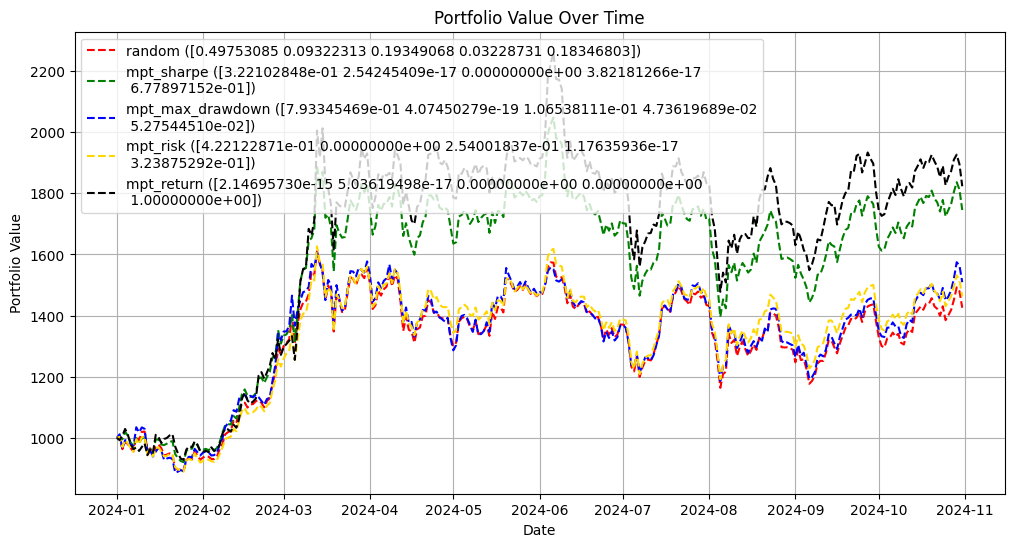

In [90]:
def plot(portfolios, weights):
    colors = ['green', 'blue', 'gold', 'black']
    portfolio_random = portfolios['random']
    plt.figure(figsize=(12, 6))
    plt.plot(portfolio_random, label=f"random ({weights['random']})", linestyle='--', color='red')
    for i, mode in enumerate(modes):
        portfolio_mpt = portfolios['mpt'][mode]
        plt.plot(portfolio_mpt, label=f"mpt_{mode} ({weights['mpt'][mode]})", linestyle='--', color=colors[i])
    plt.title('Portfolio Value Over Time')
    plt.xlabel('Date')
    plt.ylabel('Portfolio Value')
    plt.legend()
    plt.grid()
    plt.show()

plot(total_equity_dict, weights_dict)

### جمع بندی بخش اول

در این بخش عملکرد 4 مدل حاصل و همچنین مدل رندوم مقایسه شده نشان از برتر بودن عملکرد مدل مبتنی بر مجموع بازگشت و پس از آن شارپ دارد. سایر موارد عملکرد نزدیک به هم دارند.

### Plot Prices

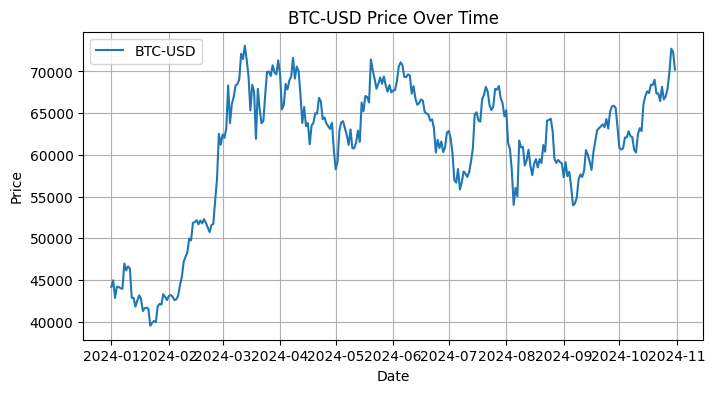

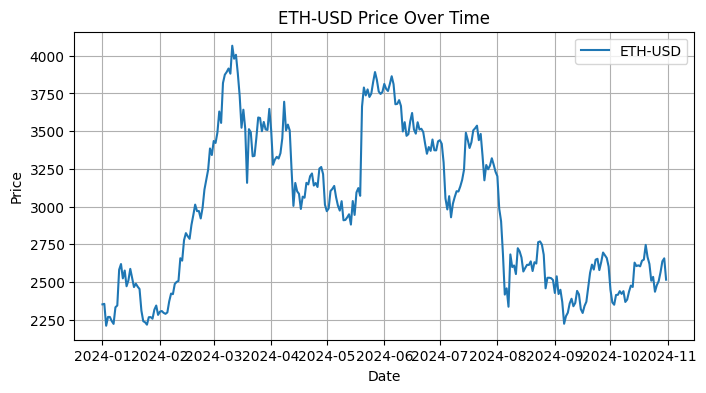

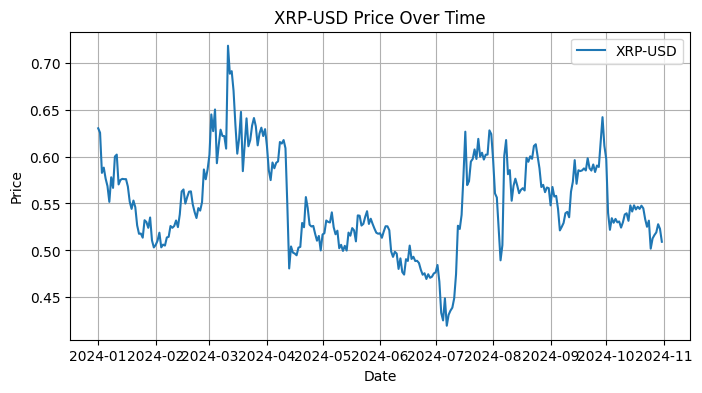

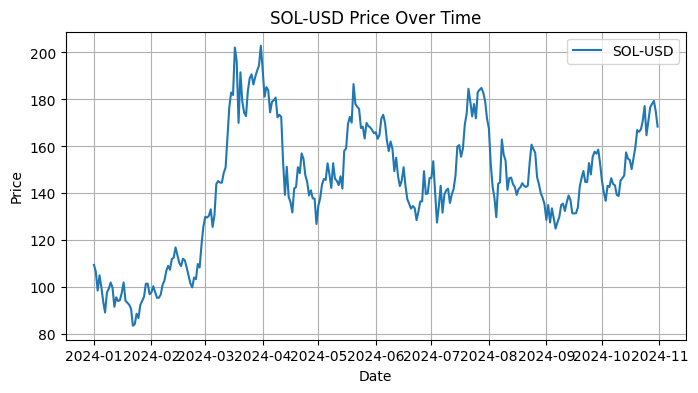

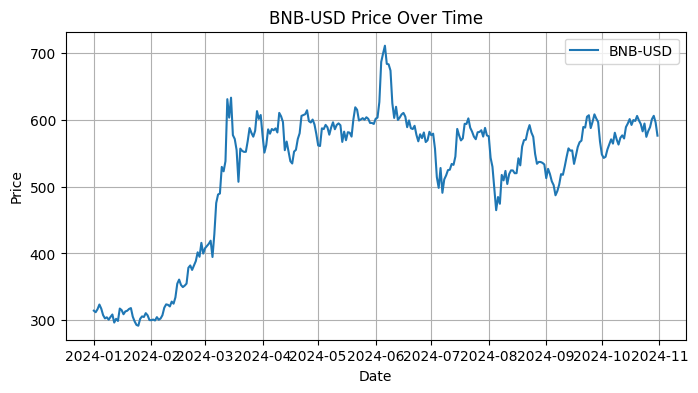

In [59]:
for coin in coins:
    plt.figure(figsize=(8, 4))
    plt.plot(all_data_df[coin], label=coin)
    plt.title(f'{coin} Price Over Time')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid()
    plt.show()

In [69]:
total_equity_ascending_dict = {'random': None, 'mpt': {}}
weights_ascending_dict = {'random': None, 'mpt': {}}

total_equity_volatile_dict = {'random': None, 'mpt': {}}
weights_volatile_dict = {'random': None, 'mpt': {}}

total_equity_descending_dict = {'random': None, 'mpt': {}}
weights_descending_dict = {'random': None, 'mpt': {}}

#### Ascending BNB (02-03)

Sharpe Ratio: 9.081261428204513
Max Drawdown: -2.60291654415493
variance: 0.10572208981319257
Expected Return: 2.9185696929257965
Sharpe Ratio: 11.290827275099073
Max Drawdown: -1.6484298560623893
variance: 0.09082470528022485
Expected Return: 3.112208938448534
Sharpe Ratio: 10.547781568496347
Max Drawdown: -1.798975005507618
variance: 0.08762227033670204
Expected Return: 2.8179558401814364
Sharpe Ratio: 9.899499529038787
Max Drawdown: -2.0297921259139025
variance: 0.0794712559575788
Expected Return: 2.381301677725065
Sharpe Ratio: 10.656456027402411
Max Drawdown: -3.0477964947978715
variance: 0.11072202628820511
Expected Return: 3.5456740874713235


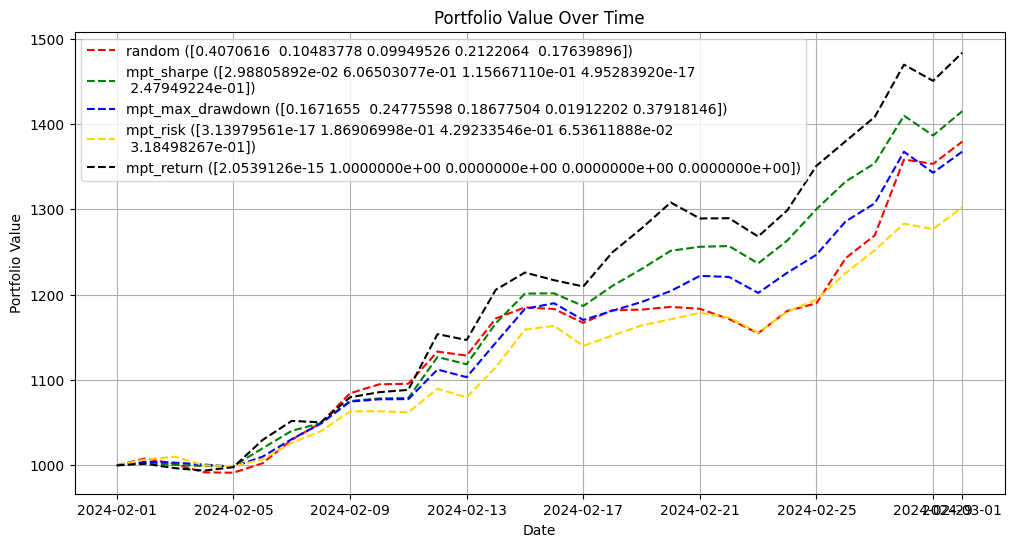

In [70]:
ascending_data_df = all_data_df['2024-02-01':'2024-03-01']

weights = random_weights(len(coins))
equity = buy_and_hold_strategy(ascending_data_df, weights)
total_equity = equity.sum(axis=1)
total_equity_ascending_dict['random'] = total_equity
weights_ascending_dict['random'] = weights
returns = ascending_data_df.pct_change().dropna()
mean_returns = returns.mean(axis=0) * len(returns)
covar_matrix = returns.cov() * len(returns)
evaluate(total_equity, returns, weights, covar_matrix)
print("="*50)

for mode in modes:
    returns = ascending_data_df.pct_change().dropna()
    mean_returns = returns.mean(axis=0) * len(returns)
    covar_matrix = returns.cov() * len(returns)
    weights = mpt_weights(len(coins), returns, objective=mode)
    equity = buy_and_hold_strategy(ascending_data_df, weights)
    total_equity = equity.sum(axis=1)
    total_equity_ascending_dict['mpt'][mode] = total_equity
    weights_ascending_dict['mpt'][mode] = weights
    evaluate(total_equity, returns, weights, covar_matrix)
    print("="*50)

plot(total_equity_ascending_dict, weights_ascending_dict)

#### Volatile BNB (01-02)

Sharpe Ratio: -1.9279485257242215
Max Drawdown: -13.893005921898268
variance: 0.1481305310496645
Expected Return: -0.6794048244877914
Sharpe Ratio: -0.2587147384022223
Max Drawdown: -15.342265954385015
variance: 0.1761425667377027
Expected Return: -0.04874996004914041
Sharpe Ratio: -1.03541344670119
Max Drawdown: -8.813889423322253
variance: 0.1152702996572368
Expected Return: -0.23948376465951823
Sharpe Ratio: -2.2557587088373836
Max Drawdown: -10.449212120024262
variance: 0.11213385085310167
Expected Return: -0.644070729575748
Sharpe Ratio: -0.2587147384001684
Max Drawdown: -15.342265954393092
variance: 0.17614256673737164
Expected Return: -0.048749960048582466


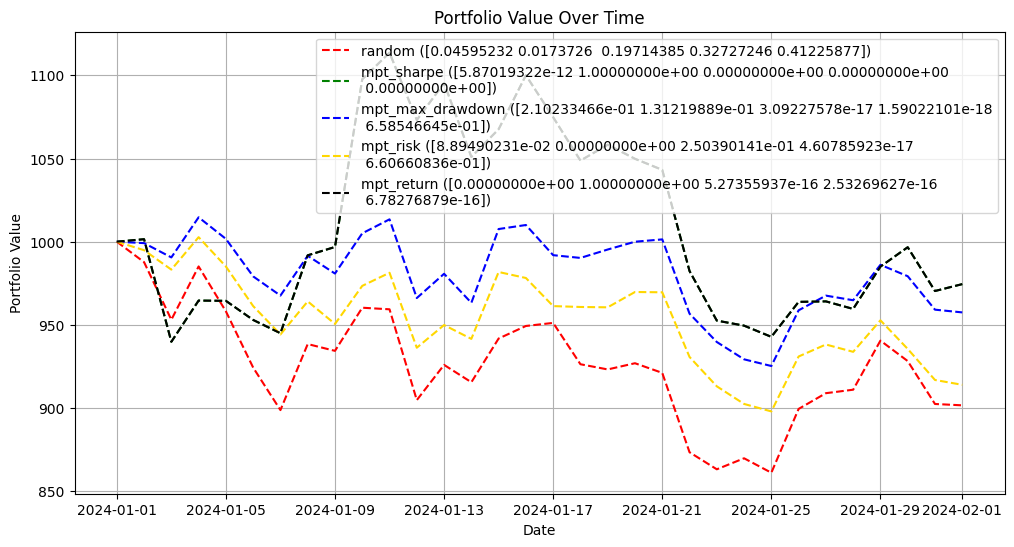

In [71]:
volatile_data_df = all_data_df['2024-01-01':'2024-02-01']
weights = random_weights(len(coins))
equity = buy_and_hold_strategy(volatile_data_df, weights)
total_equity = equity.sum(axis=1)
total_equity_volatile_dict['random'] = total_equity
weights_volatile_dict['random'] = weights
returns = volatile_data_df.pct_change().dropna()
mean_returns = returns.mean(axis=0) * len(returns)
covar_matrix = returns.cov() * len(returns)
evaluate(total_equity, returns, weights, covar_matrix)
print("="*50)

for mode in modes:
    returns = volatile_data_df.pct_change().dropna()
    mean_returns = returns.mean(axis=0) * len(returns)
    covar_matrix = returns.cov() * len(returns)
    weights = mpt_weights(len(coins), returns, objective=mode)
    equity = buy_and_hold_strategy(volatile_data_df, weights)
    total_equity = equity.sum(axis=1)
    total_equity_volatile_dict['mpt'][mode] = total_equity
    weights_volatile_dict['mpt'][mode] = weights
    evaluate(total_equity, returns, weights, covar_matrix)
    print("="*50)

plot(total_equity_volatile_dict, weights_volatile_dict)

#### Descending BNB (06-07)

Sharpe Ratio: -2.4656443358395217
Max Drawdown: -15.32236246487814
variance: 0.10527021740267233
Expected Return: -0.6413175102572841
Sharpe Ratio: -0.6942450000938148
Max Drawdown: -20.268382713316207
variance: 0.16211717323563798
Expected Return: -0.24521114931205992
Sharpe Ratio: -2.6897114170825698
Max Drawdown: -10.682531082807786
variance: 0.09604278560480005
Expected Return: -0.6654839411277572
Sharpe Ratio: -3.1259534915934144
Max Drawdown: -12.815615880009842
variance: 0.08428786045152824
Expected Return: -0.6690389998897361
Sharpe Ratio: -0.694245000093811
Max Drawdown: -20.268382713316193
variance: 0.16211717323563787
Expected Return: -0.24521114931205956


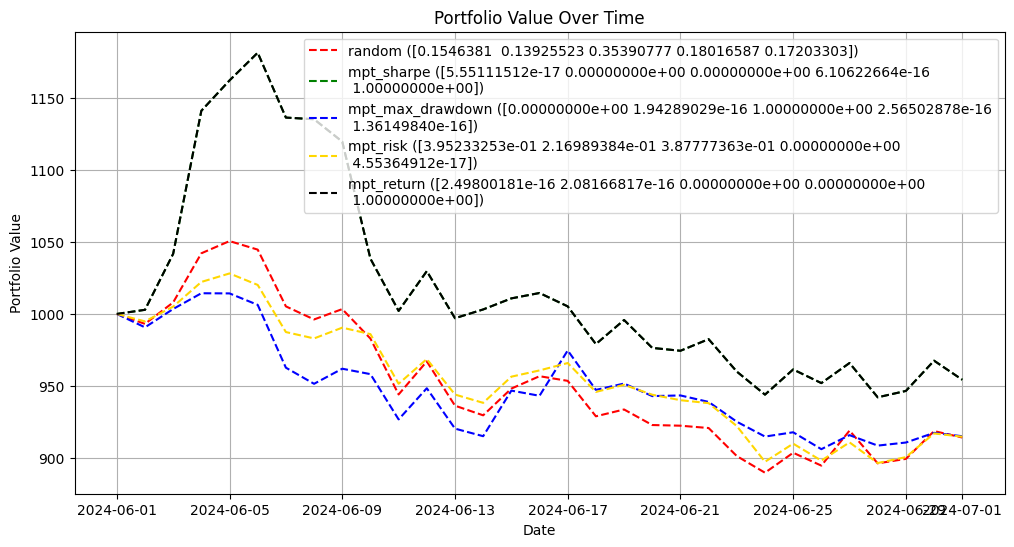

In [72]:
descending_data_df = all_data_df['2024-06-01':'2024-07-01']

weights = random_weights(len(coins))
equity = buy_and_hold_strategy(descending_data_df, weights)
total_equity = equity.sum(axis=1)
total_equity_descending_dict['random'] = total_equity
weights_descending_dict['random'] = weights
returns = descending_data_df.pct_change().dropna()
mean_returns = returns.mean(axis=0) * len(returns)
covar_matrix = returns.cov() * len(returns)
evaluate(total_equity, returns, weights, covar_matrix)
print("="*50)

for mode in modes:
    returns = descending_data_df.pct_change().dropna()
    mean_returns = returns.mean(axis=0) * len(returns)
    covar_matrix = returns.cov() * len(returns)
    weights = mpt_weights(len(coins), returns, objective=mode)
    equity = buy_and_hold_strategy(descending_data_df, weights)
    total_equity = equity.sum(axis=1)
    total_equity_descending_dict['mpt'][mode] = total_equity
    weights_descending_dict['mpt'][mode] = weights
    evaluate(total_equity, returns, weights, covar_matrix)
    print("="*50)

plot(total_equity_descending_dict, weights_descending_dict)

بازه های انتخاب شده برای صعودی و نزولی برای تمام کوین ها به همان شکل است و منجر به نتیجه مطلوب مشابه قسمت قبل شده 

با توجه به ماهیت رفتار قیمت ها در این بازه زمانی و نتایح حاصل استفاده از مدل مبتنی بر مجموع بازگشت ها نتیجه بهتری میدهد

## Part 2

In [81]:
start_date, end_date = '2024-11-02', '2024-12-02'

all_data_new = {}
Index_new = None

for coin in coins:
    data = yf.download(coin, start=start_date, end=end_date)
    all_data_new[coin] = data
    Index_new = data.index

all_data_new_df = pd.DataFrame(index=Index_new)
for coin in coins:
    all_data_new_df[coin] = all_data_new[coin]['Close']

total_equity_new_dict = {'random': None, 'mpt': {}}
weights_new_dict = {'random': None, 'mpt': {}}

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


#### Plot Prices

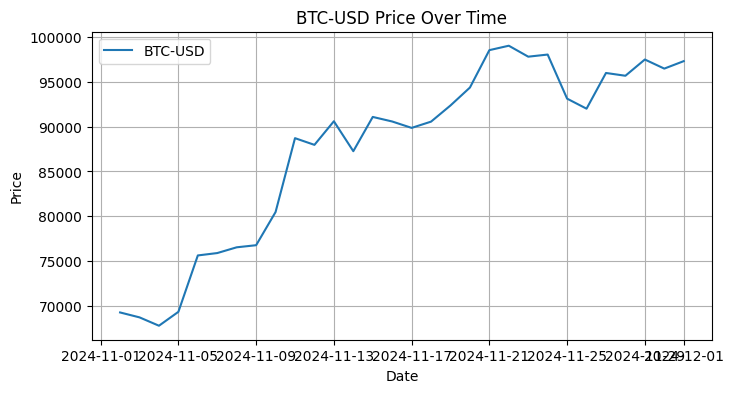

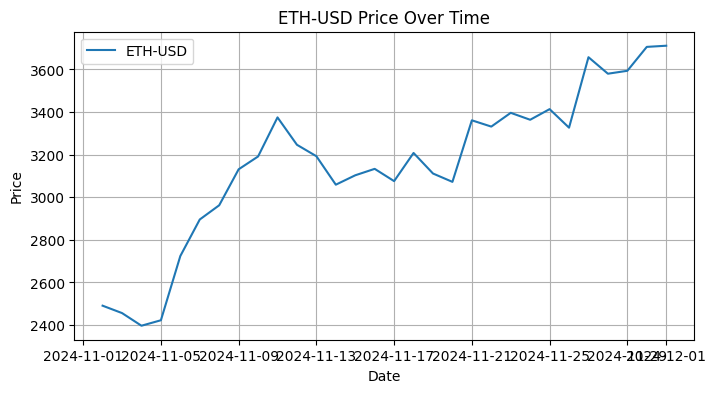

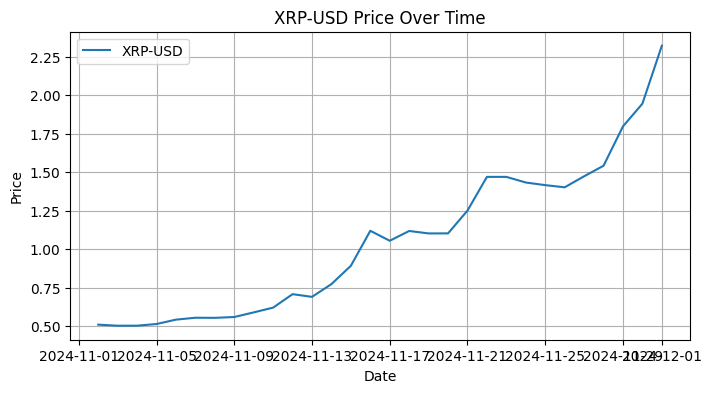

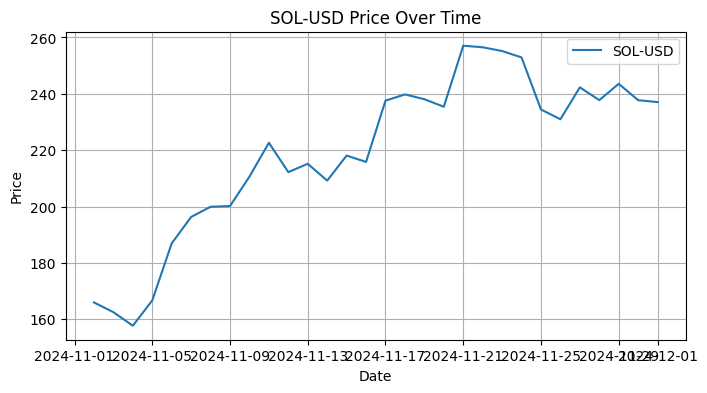

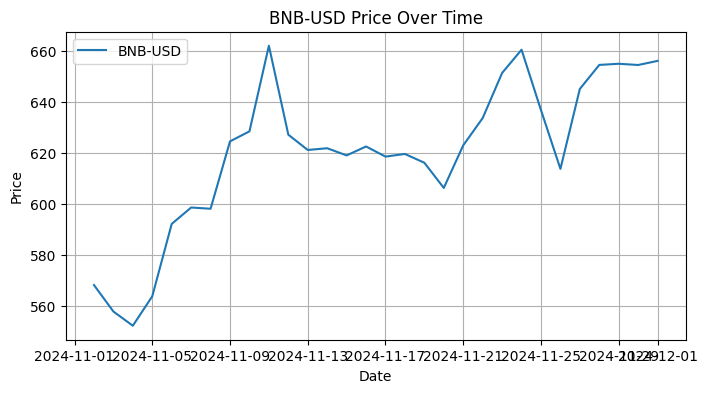

In [82]:
for coin in coins:
    plt.figure(figsize=(8, 4))
    plt.plot(all_data_new_df[coin], label=coin)
    plt.title(f'{coin} Price Over Time')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid()
    plt.show()

### Trading Using Random Weights

In [92]:
weights = random_weights(len(coins))
equity = buy_and_hold_strategy(all_data_new_df, weights)
total_equity = equity.sum(axis=1)
total_equity_new_dict['random'] = total_equity
weights_new_dict['random'] = weights
returns = all_data_new_df.pct_change().dropna()
mean_returns = returns.mean(axis=0) * len(returns)
covar_matrix = returns.cov() * len(returns)
evaluate(total_equity, returns, weights, covar_matrix)

Sharpe Ratio: 10.785456804851345
Max Drawdown: -5.06717010733998
variance: 0.1526763846992571
Expected Return: 4.475238175418758


### Trading Using MPT

In [93]:
returns = all_data_df.pct_change().dropna()
mean_returns = returns.mean(axis=0) * len(returns)
covar_matrix = returns.cov() * len(returns)

for mode in modes:
    weights = weights_dict['mpt'][mode]
    equity = buy_and_hold_strategy(all_data_new_df, weights)
    total_equity = equity.sum(axis=1)
    total_equity_new_dict['mpt'][mode] = total_equity
    weights_new_dict['mpt'][mode] = weights
    evaluate(total_equity, returns, weights, covar_matrix)
    print("="*50)

Sharpe Ratio: 4.584171731320667
Max Drawdown: -6.737584916414761
variance: 0.47736664632465814
Expected Return: 0.5731313892008081
Sharpe Ratio: 9.672344718599701
Max Drawdown: -6.58655636187562
variance: 0.4699820439599573
Expected Return: 0.4384843388816581
Sharpe Ratio: 11.653667175803843
Max Drawdown: -5.324284495222133
variance: 0.44123607290260775
Expected Return: 0.3938298721453231
Sharpe Ratio: 3.0743272871136815
Max Drawdown: -8.425863766971908
variance: 0.5299976659568757
Expected Return: 0.6167548627099785


### Plot Portfolios

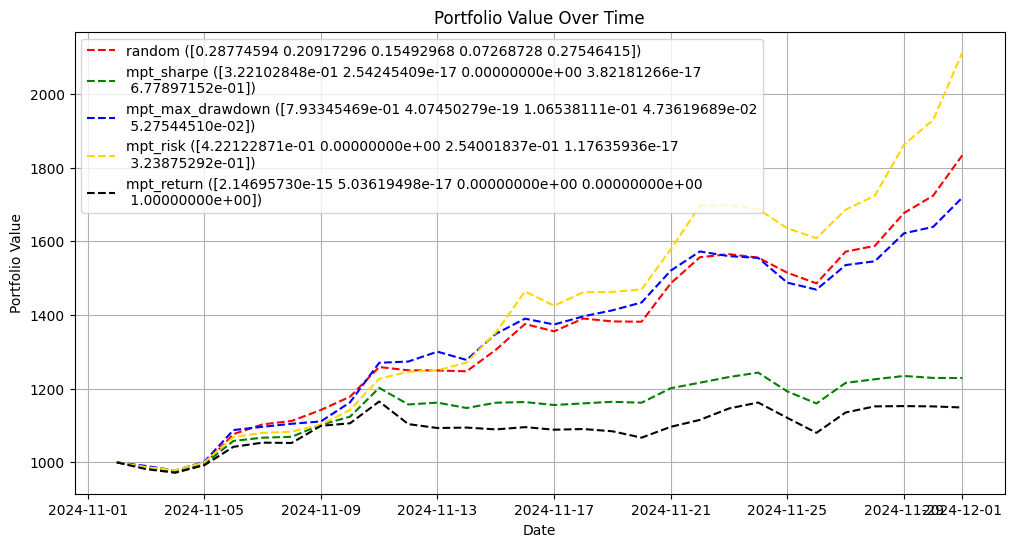

In [94]:
plot(total_equity_new_dict, weights_new_dict)

نتایج برای تست، مطابق ترین نبوده و مدل های مبتنی بر شارپ و ریترن ضعیف ترین نتایج را داشته

توضیح: برای ریترن که محاسبه ساده است، در تمام طول هر دو بازه ترین و تست انجام دادم و نتایج نشان داد در بازه ترین

BNB 

که عمده خرید در ترین بوده بیشترین رشد را داشته و لذا عمده وزن به آن اختصاص داده شده درحالی که در بازه تست رشد آن کاهش داشته و از طرفی 

BTC , ETH 

که برای مثال در مدل رندوم وزن بیشتری گرفته اند و سود بیشتری داده، رشد بیشتری را تجربه کرده اند. پس با توجه به تغییر رفتار کوین ها در بازه ترین و تست نمیتوان به مدل

mpt 
 
استناد کرد و انتظار روند سودده بهینه دائم داشت